# The Chess Code

## A Data-Driven Analysis of Chess Game Outcomes and Player Skill

**Student Name:** Din Muhammad Rezwoan  
**Dataset:** Chess Game Dataset (Lichess) - https://www.kaggle.com/datasets/datasnaek/chess  
**Source:** Kaggle  
**Tools:** Python, Pandas, NumPy, Matplotlib, Scikit-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import shutil
import os

print("All libraries imported successfully")

All libraries imported successfully


## Section 1 - Load Dataset


In [2]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("datasnaek/chess")
print("Downloaded to:", path)

# Copy games.csv into project /data folder
src = os.path.join(path, 'games.csv')
dst = os.path.join(os.getcwd(), 'data', 'games.csv')

if not os.path.exists(dst):
    shutil.copy(src, dst)
    print("games.csv copied to /data folder")
else:
    print("games.csv already exists in /data folder")

# Load dataset
df = pd.read_csv(dst)
print(f"\nDataset loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Downloaded to: C:\Users\Admin\.cache\kagglehub\datasets\datasnaek\chess\versions\1
games.csv already exists in /data folder

Dataset loaded successfully
Rows: 20058
Columns: 16


## Section 2 - Data Understanding


In [3]:
print("Column Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)

Column Names:
Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='str')

Data Types:
id                    str
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status        str
winner                str
increment_code        str
white_id              str
white_rating      float64
black_id              str
black_rating        int64
moves                 str
opening_eco           str
opening_name          str
opening_ply         int64
dtype: object


In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500.0,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322.0,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496.0,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439.0,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523.0,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [5]:
print("Numerical Summary:")
df.describe()

Numerical Summary:


,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,19758.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.480970,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.478336,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1566.500000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing %
white_rating            300        1.5
opening_eco             601        3.0
opening_name            802        4.0


In [7]:
print("Victory Type Distribution:")
print(df['victory_status'].value_counts())
print("\nWinner Distribution:")
print(df['winner'].value_counts(dropna=False))
print("\nRated vs Casual:")
print(df['rated'].value_counts())


Victory Type Distribution:
victory_status
resign       11147
mate          6325
outoftime     1680
draw           906
Name: count, dtype: int64

Winner Distribution:
winner
white    10001
black     9107
draw       950
Name: count, dtype: int64

Rated vs Casual:
rated
True     16155
False     3903
Name: count, dtype: int64


In [8]:
print(df.isnull().sum())
print("\nTotal rows:", len(df))

id                  0
rated               0
created_at          0
last_move_at        0
turns               0
victory_status      0
winner              0
increment_code      0
white_id            0
white_rating      300
black_id            0
black_rating        0
moves               0
opening_eco       601
opening_name      802
opening_ply         0
dtype: int64

Total rows: 20058


### Data Understanding Summary

- The dataset has **20,058 rows and 16 columns**, with a mix of strings, integers, booleans, and floats.
- Three columns have missing values: `white_rating` (300 rows, 1.5%), `opening_eco` (601 rows, 3.0%), and `opening_name` (802 rows, 4.0%).
- `winner` has no missing values. Drawn games are already recorded as `"draw"` by Lichess.
- `victory_status` is imbalanced: resign accounts for the majority of games, with draw being the rarest outcome.
- `created_at` and `last_move_at` are stored as Unix millisecond timestamps that cannot be used directly.
- `increment_code` stores both time base and increment as a single string like `"5+3"` and needs splitting.


## Section 3 - Data Cleaning


**Step 1 - Compute Estimated Game Duration:** `created_at` and `last_move_at` were stored as Unix milliseconds with identical precision, making their difference always zero. Game duration was instead estimated using the formula `(time_base * 2) + (turns * time_increment / 60)`, which calculates total clock time from the time control settings and number of moves. `increment_code` was split into `time_base` and `time_increment` as separate integer columns and the original string column was dropped along with the unusable timestamps.


In [9]:
# Split increment_code into two usable columns
df['time_base'] = df['increment_code'].str.split('+').str[0].astype(float)
df['time_increment'] = df['increment_code'].str.split('+').str[1].astype(float)

# Estimate game duration: both players use base time + each move adds increment seconds
df['game_duration_mins'] = ((df['time_base'] * 2) + (df['turns'] * df['time_increment'] / 60)).round(2)

# Drop unusable timestamp columns and original increment_code
df.drop(columns=['created_at', 'last_move_at', 'increment_code'], inplace=True)

print("Done")
print(df[['time_base', 'time_increment', 'turns', 'game_duration_mins']].head(10))

Done
   time_base  time_increment  turns  game_duration_mins
0       15.0             2.0     13               30.43
1        5.0            10.0     16               12.67
2        5.0            10.0     61               20.17
3       20.0             0.0     61               40.00
4       30.0             3.0     95               64.75
5       10.0             0.0      5               20.00
6       10.0             0.0     33               20.00
7       15.0            30.0      9               34.50
8       15.0             0.0     66               30.00
9       10.0             0.0    119               20.00


**Step 2 - Drop Rows with Missing Values:** Three columns had missing entries: `white_rating` (300 rows), `opening_eco` (601 rows), and `opening_name` (802 rows). Since `winner` already uses `"draw"` for tied games, any remaining nulls are genuinely incomplete records. All rows with any null were dropped, removing 1,678 rows (8.4% of the dataset). The remaining 18,380 rows have no missing values.


In [10]:
before = len(df)

df.dropna(inplace=True)

after = len(df)
print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Rows dropped: {before - after}")
print(f"\nRemaining null values:")
print(df.isnull().sum().sum())

Rows before: 20058
Rows after: 18380
Rows dropped: 1678

Remaining null values:
0


**Step 3 - Remove Duplicates:** Duplicate game IDs produce inflated counts and distort any aggregation. 802 duplicate rows were found and removed based on the `id` column, leaving 17,578 unique games.


In [11]:
# Step 3 — Remove duplicate games
before = len(df)
df.drop_duplicates(subset='id', inplace=True)
print(f"Duplicates removed: {before - len(df)}")
print(f"Rows remaining: {len(df)}")

Duplicates removed: 802
Rows remaining: 17578


**Step 4 - Drop Moves Column:** The `moves` column contains the full game notation as a text string. Analyzing individual moves requires a chess engine and is outside the scope of this project. The column was dropped to keep the dataset clean.


In [12]:
# Step 4 — Drop moves column
df.drop(columns=['moves'], inplace=True)
print("Final shape:", df.shape)

Final shape: (17578, 15)


**Step 5 - Remove Turn Count Outliers:** Games with a z-score above 3 on the `turns` column (games with more than ~160 turns) are abnormally long and likely caused by stalling or abandoned sessions. 147 such games were removed, leaving 17,431 rows for analysis.


In [13]:
before = len(df)
z = (df['turns'] - df['turns'].mean()) / df['turns'].std()
df = df[np.abs(z) <= 3].copy()
print(f"Outliers removed: {before - len(df)}")
print(f"Rows remaining: {len(df)}")

Outliers removed: 147
Rows remaining: 17431


## Section 4 - Feature Engineering


In [14]:
# Feature 1 — Rating gap (positive = white stronger, negative = black stronger)
df['rating_gap'] = df['white_rating'] - df['black_rating']

# Feature 2 — Average rating (overall skill level of the game)
df['avg_rating'] = ((df['white_rating'] + df['black_rating']) / 2).round(0)

# Feature 3 — Rating tier
df['rating_tier'] = pd.cut(
    df['avg_rating'],
    bins=[0, 1200, 1500, 1800, 2100, 3000],
    labels=['Beginner', 'Intermediate', 'Advanced', 'Expert', 'Master']
)

# Feature 4 — Time control category
df['time_control_category'] = pd.cut(
    df['time_base'],
    bins=[0, 3, 5, 10, 9999],
    labels=['Bullet', 'Blitz', 'Rapid', 'Classical']
)

# Feature 5 — Opening family
df['opening_family'] = df['opening_name'].str.split(':').str[0].str.strip()

# Feature 6 — Upset (underdog won)
df['is_upset'] = (
    ((df['rating_gap'] > 0) & (df['winner'] == 'black')) |
    ((df['rating_gap'] < 0) & (df['winner'] == 'white'))
)

print("Features created successfully")
print(df[['rating_gap', 'avg_rating', 'rating_tier', 
          'time_control_category', 'opening_family', 'is_upset']].head(10))

Features created successfully
   rating_gap  avg_rating   rating_tier time_control_category  \
0       309.0      1346.0  Intermediate             Classical   
1        61.0      1292.0  Intermediate                 Blitz   
2        -4.0      1498.0  Intermediate                 Blitz   
3       -15.0      1446.0  Intermediate             Classical   
4        54.0      1496.0  Intermediate             Classical   
5       248.0      1126.0      Beginner                 Rapid   
6        97.0      1472.0  Intermediate                 Rapid   
7      -695.0      1760.0      Advanced             Classical   
8        47.0      1416.0  Intermediate             Classical   
9       172.0      1295.0  Intermediate                 Rapid   

           opening_family  is_upset  
0            Slav Defense     False  
1     Nimzowitsch Defense      True  
2        King's Pawn Game      True  
3       Queen's Pawn Game      True  
4        Philidor Defense     False  
5        Sicilian Defense 

## Section 5 — Data Analysis


In [15]:
# Analysis 1 — Victory type distribution
print("=== Victory Status Distribution ===")
print(df['victory_status'].value_counts())
print(df['victory_status'].value_counts(normalize=True).round(3))

=== Victory Status Distribution ===
victory_status
resign       9819
mate         5431
outoftime    1449
draw          732
Name: count, dtype: int64
victory_status
resign       0.563
mate         0.312
outoftime    0.083
draw         0.042
Name: proportion, dtype: float64


In [16]:
# Analysis 2 - Subgroup #1: Victory type by rating tier
print("=== Victory Type by Rating Tier ===")
tier_victory = df.groupby('rating_tier', observed=True)['victory_status'].value_counts(normalize=True).unstack().round(3)
print(tier_victory)

=== Victory Type by Rating Tier ===
victory_status   draw   mate  outoftime  resign
rating_tier                                    
Beginner        0.046  0.394      0.094   0.466
Intermediate    0.035  0.393      0.071   0.501
Advanced        0.039  0.296      0.088   0.577
Expert          0.051  0.206      0.091   0.652
Master          0.083  0.119      0.093   0.705


In [17]:
# Analysis 3 - Subgroup #2: Victory type by time control
print("=== Victory Type by Time Control ===")
time_victory = df.groupby('time_control_category', observed=True)['victory_status'].value_counts(normalize=True).unstack().round(3)
print(time_victory)

=== Victory Type by Time Control ===
victory_status          draw   mate  outoftime  resign
time_control_category                                 
Bullet                 0.016  0.368      0.088   0.528
Blitz                  0.036  0.304      0.093   0.567
Rapid                  0.037  0.316      0.096   0.551
Classical              0.052  0.306      0.055   0.586


In [18]:
# Analysis 4 — Relationship: rating gap vs game length (NumPy #1)
corr = np.corrcoef(df['rating_gap'].abs(), df['turns'])[0, 1]
print(f"Rating Gap vs Turns Correlation: {corr:.4f}")

Rating Gap vs Turns Correlation: -0.1250


In [19]:
# Analysis 5 - Opening win rate across all openings with enough games
df['white_wins'] = (df['winner'] == 'white').astype(int)
opening_winrate = df.groupby('opening_family').agg(
    white_win_rate=('white_wins', 'mean'),
    total_games=('white_wins', 'count')
).query('total_games > 50').sort_values('white_win_rate', ascending=True)
print(f'Openings with 50+ games: {len(opening_winrate)}')
print(f'Above 50% win rate: {(opening_winrate["white_win_rate"] > 0.5).sum()}')
print(f'Below 50% win rate: {(opening_winrate["white_win_rate"] <= 0.5).sum()}')
print(opening_winrate)

Openings with 50+ games: 54
Above 50% win rate: 27
Below 50% win rate: 27
                         white_win_rate  total_games
opening_family                                      
Center Game                    0.315789           95
Van't Kruijs Opening           0.326923          312
Mieses Opening                 0.377778           90
Pirc Defense                   0.386364           88
Indian Game                    0.400709          282
Benoni Defense                 0.403509           57
Bird Opening                   0.410448          134
Giuoco Piano                   0.418367           98
Hungarian Opening              0.430556          144
Nimzo-Larsen Attack            0.435714          140
Modern Defense                 0.443878          196
Owen Defense                   0.445255          137
Queen's Pawn Game #2           0.455446          101
Ponziani Opening               0.456140           57
Semi-Slav Defense              0.456522           92
Sicilian Defense         

In [20]:
# Analysis 6 - Extended game outlier summary (NumPy z-score)
z_scores = (df['turns'] - df['turns'].mean()) / df['turns'].std()
df['turns_zscore'] = z_scores
near_outliers = df[np.abs(z_scores) > 2.5]
print("=== Near-Outlier Games (|z| > 2.5) ===")
print(f"Count: {len(near_outliers)}")
print(near_outliers[['turns', 'turns_zscore', 'victory_status', 'rating_tier']].head(10))

=== Near-Outlier Games (|z| > 2.5) ===
Count: 310
     turns  turns_zscore victory_status   rating_tier
148    156      3.044176           mate  Intermediate
176    144      2.666140      outoftime        Expert
180    158      3.107183           mate        Expert
213    159      3.138686           mate  Intermediate
220    150      2.855158           draw  Intermediate
433    148      2.792152      outoftime      Advanced
584    148      2.792152           draw        Expert
600    158      3.107183           draw        Expert
769    153      2.949667           draw        Master
827    154      2.981170         resign      Advanced


In [21]:
# Analysis 7 - Draw rate by rating tier
df['is_draw'] = (df['winner'] == 'draw').astype(int)
draw_rate = df.groupby('rating_tier', observed=True)['is_draw'].mean().round(4)
print("=== Draw Rate by Rating Tier ===")
print(draw_rate)

=== Draw Rate by Rating Tier ===
rating_tier
Beginner        0.0489
Intermediate    0.0361
Advanced        0.0420
Expert          0.0533
Master          0.0829
Name: is_draw, dtype: float64


In [22]:
# Analysis 8 - Upset rate by time control
upset_rate = df.groupby('time_control_category', observed=True)['is_upset'].mean().round(4)
print("=== Upset Rate by Time Control ===")
print(upset_rate)

=== Upset Rate by Time Control ===
time_control_category
Bullet       0.3520
Blitz        0.3144
Rapid        0.3316
Classical    0.3299
Name: is_upset, dtype: float64


### Analysis Summary

- Resign accounts for 56.3% of all 17,431 games, mate 31.2%, outoftime 8.3%, and draw 4.2%.
- Resign rate increases from 46.6% at Beginner level to 70.5% at Master level. Timeout rate stays relatively flat across tiers, ranging between 7.1% and 9.4%.
- Classical format has the lowest timeout rate at 5.5%, compared to Rapid at 9.6%, confirming that time pressure is a direct factor in how games end.
- The correlation between absolute rating gap and number of turns is -0.125, meaning games between mismatched players tend to end faster.
- Of the 54 opening families with 50 or more games, exactly 27 favor white (above 50%) and 27 favor black or are balanced. The best opening for white is Queen's Pawn at 67.8% and the worst is Center Game at 31.6%.
- Draw rate is lowest at Intermediate level (3.61%) and highest at Master level (8.29%).
- Bullet games have the highest upset rate at 35.2%, compared to Classical at 33.0%, showing that faster time controls give the lower-rated player a slightly better chance.


## Section 6 - Visualization


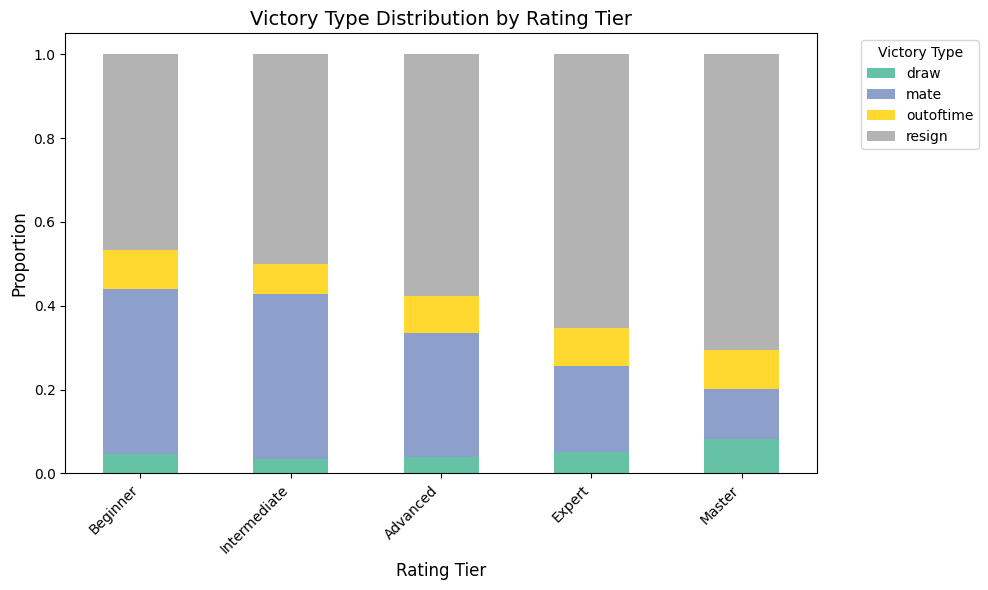

Chart 1 saved


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

tier_victory.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')

ax.set_title('Victory Type Distribution by Rating Tier', fontsize=14)
ax.set_xlabel('Rating Tier', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.legend(title='Victory Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
os.makedirs('images/charts', exist_ok=True)
plt.savefig('images/charts/chart1_victory_by_tier.png', dpi=150)
plt.show()
print('Chart 1 saved')

**Chart 1 - Victory Type by Rating Tier:** Each bar shows the proportion of how games ended within that rating group. Resign rate grows from 46.6% at Beginner to 70.5% at Master, while mate drops from 39.4% to 11.9%. This shows that stronger players recognize losing positions earlier and resign rather than playing until checkmate.


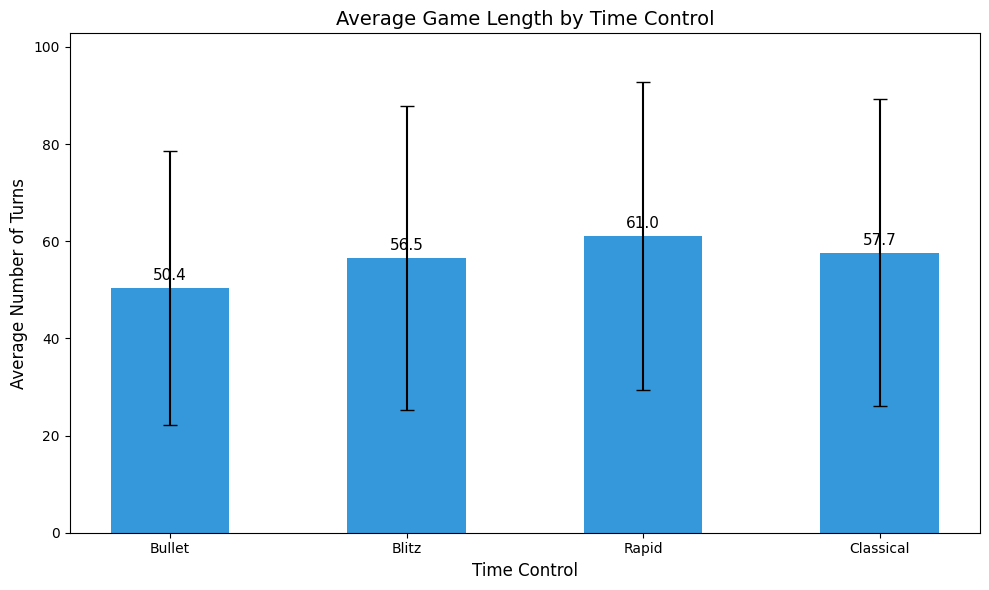

Chart 2 saved


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

time_categories = ['Bullet', 'Blitz', 'Rapid', 'Classical']
mean_turns = [df[df['time_control_category'] == time_category]['turns'].mean() for time_category in time_categories]
std_turns = [df[df['time_control_category'] == time_category]['turns'].std() for time_category in time_categories]

bars = ax.bar(time_categories, mean_turns, color='#3498db', width=0.5, yerr=std_turns, capsize=5, error_kw={'linewidth': 1.5})

for bar, mean in zip(bars, mean_turns):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{mean:.1f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Average Game Length by Time Control', fontsize=14)
ax.set_xlabel('Time Control', fontsize=12)
ax.set_ylabel('Average Number of Turns', fontsize=12)
ax.set_ylim(0, max(mean_turns) + max(std_turns) + 10)

plt.tight_layout()
plt.savefig('images/charts/chart2_length_by_timecontrol.png', dpi=150)
plt.show()
print('Chart 2 saved')

**Chart 2 - Average Game Length by Time Control:** The bar height shows the average number of turns per game for each format. Bullet games have the lowest average turn count, and the error bars show their spread is tighter compared to slower formats. Classical and Rapid games have higher averages with more variation, since players have more time to play complex positions without running out of time.


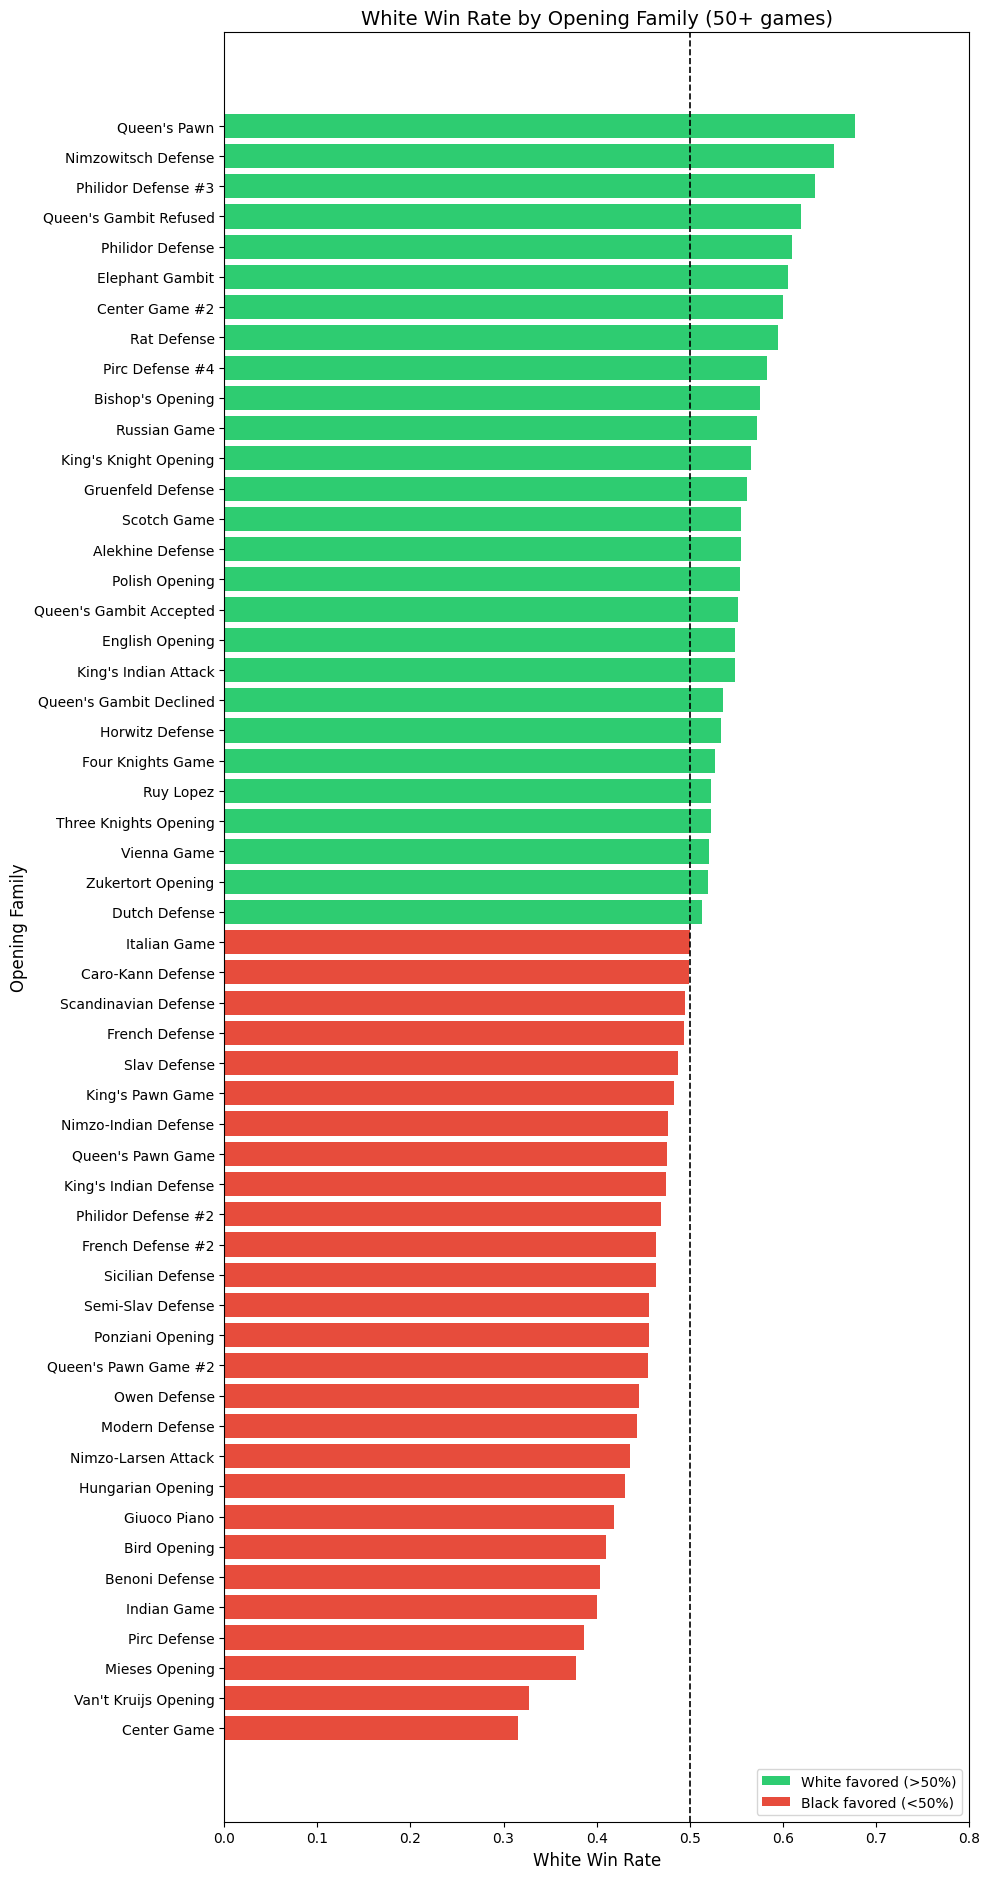

Chart 3 saved


In [25]:
fig, ax = plt.subplots(figsize=(10, max(6, len(opening_winrate) * 0.35)))

colors = ['#2ecc71' if x > 0.5 else '#e74c3c'
          for x in opening_winrate['white_win_rate']]

ax.barh(opening_winrate.index, opening_winrate['white_win_rate'], color=colors)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.2, label='50% baseline')
ax.set_title('White Win Rate by Opening Family (50+ games)', fontsize=14)
ax.set_xlabel('White Win Rate', fontsize=12)
ax.set_ylabel('Opening Family', fontsize=12)
ax.legend()
ax.set_xlim(0, 0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='White favored (>50%)'),
    Patch(facecolor='#e74c3c', label='Black favored (<50%)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('images/charts/chart3_opening_winrate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved')

**Chart 3 - Opening Win Rate by Family:** Of the 54 openings with 50 or more games, exactly half favor white and half favor black or are balanced. The Queen's Pawn opening gives white the highest win rate at 67.8%, while the Center Game is the worst for white at only 31.6%. The chart shows that opening choice has a real influence on outcomes, with a spread of over 35 percentage points from best to worst.


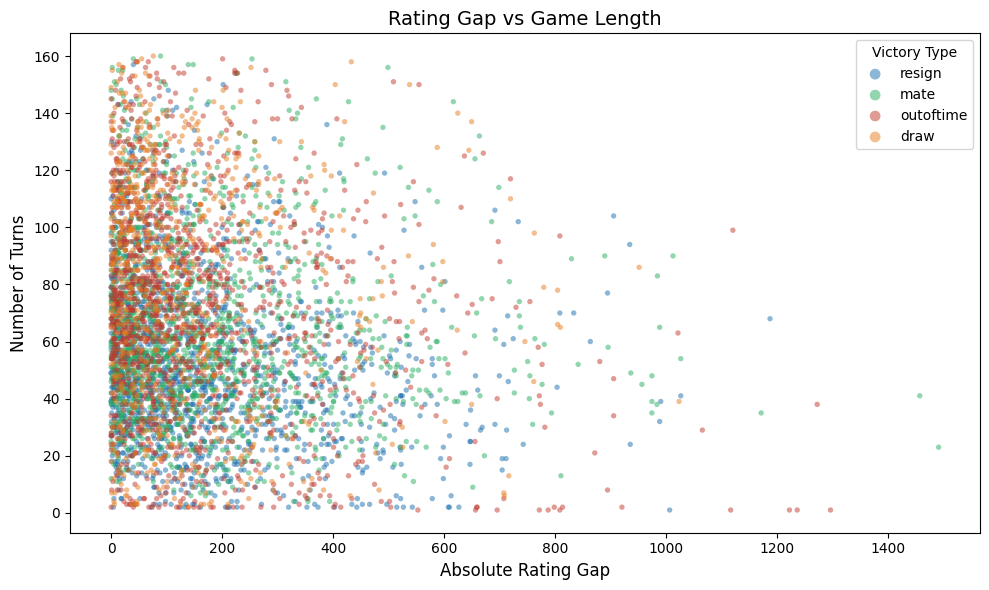

Chart 4 saved


In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {
    'resign':    '#1a6faf',
    'mate':      '#27ae60',
    'outoftime': '#c0392b',
    'draw':      '#e67e22'
}

for vtype, color in colors_map.items():
    subset = df[df['victory_status'] == vtype].sample(
        min(1500, len(df[df['victory_status'] == vtype])), random_state=42
    )
    ax.scatter(subset['rating_gap'].abs(), subset['turns'],
               c=color, label=vtype, alpha=0.5, s=15, edgecolors='none')

ax.set_title('Rating Gap vs Game Length', fontsize=14)
ax.set_xlabel('Absolute Rating Gap', fontsize=12)
ax.set_ylabel('Number of Turns', fontsize=12)
ax.legend(title='Victory Type', markerscale=2)

plt.tight_layout()
plt.savefig('images/charts/chart4_gap_vs_turns.png', dpi=150)
plt.show()
print('Chart 4 saved')

**Chart 4 - Rating Gap vs Game Length:** Each point represents one game. The correlation between absolute rating gap and number of turns is -0.125, confirming that larger mismatches produce shorter games. Resign endings cluster across all gap sizes while mate and timeout endings appear more at lower gap values, where both players are closer in skill and neither gives up early.


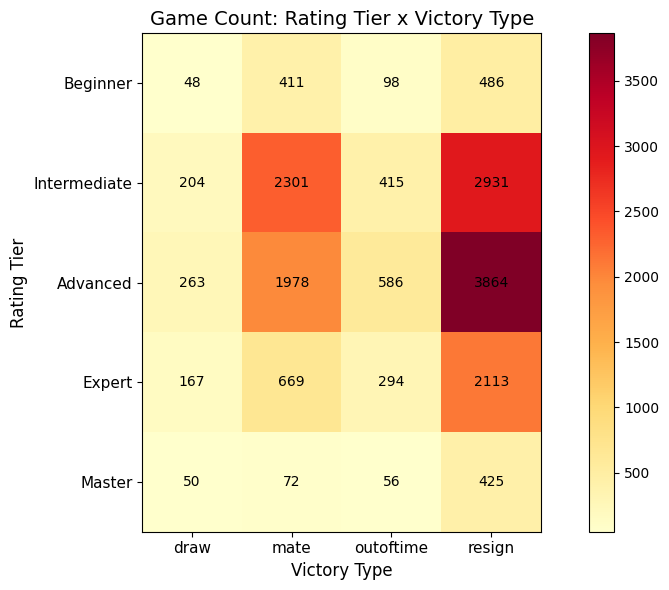

Chart 5 saved


In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

heatmap_data = df.groupby(
    ['rating_tier', 'victory_status'], observed=True
).size().unstack().fillna(0)

im = ax.imshow(heatmap_data.values, cmap='YlOrRd')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticklabels(heatmap_data.index, fontsize=11)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(j, i, int(heatmap_data.values[i, j]),
                ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax)
ax.set_title('Game Count: Rating Tier x Victory Type', fontsize=14)
ax.set_xlabel('Victory Type', fontsize=12)
ax.set_ylabel('Rating Tier', fontsize=12)

plt.tight_layout()
plt.savefig('images/charts/chart5_heatmap.png', dpi=150)
plt.show()
print('Chart 5 saved')

**Chart 5 - Heatmap:** The Advanced tier has the highest game count, making it the darkest row. Resign is the dominant ending in every tier. Timeout counts are spread across all tiers rather than concentrated at the bottom, which matches the analysis showing timeout rate stays between 7% and 9% regardless of skill level. Draw counts visibly increase at Expert and Master tier.


## Section 7 - Findings and Discussion

1. **Resign is the dominant game ending across all skill levels.** It accounts for 56.3% of all 17,431 games. Its proportion grows from 46.6% at Beginner level to 70.5% at Master level, confirming that recognizing a lost position is a skill that improves with rating.

2. **Mate endings decrease sharply with rating.** Beginners end 39.4% of games by checkmate while Masters only reach checkmate in 11.9% of games. Higher-rated players resign well before the final move.

3. **Time control affects how games end more than it affects game length.** Classical games have a timeout rate of only 5.5% compared to 9.6% in Rapid and 8.8% in Bullet. However, average game length in turns is similar across all formats, meaning slower formats produce more complex positions but not necessarily longer move sequences.

4. **Opening choice has a measurable effect on outcomes.** Across 54 openings with 50 or more games, white win rates range from 31.6% (Center Game) to 67.8% (Queen's Pawn), a spread of over 36 percentage points. Half of all openings favor white and half favor black or are balanced.

5. **Draw rate peaks at Master tier.** Masters draw 8.29% of games compared to just 3.61% at Intermediate level. This is consistent with the idea that high-level play leads to positions where neither side can make progress.

6. **Upset rate is highest in Bullet games at 35.2%**, compared to 33.0% in Classical. This small but consistent difference suggests that faster time controls reduce the advantage that higher-rated players normally hold.


## Section 8 - Limitations

1. **Correlation does not imply causation.** All relationships found in this analysis are associative. For example, higher rating correlating with more resign endings does not mean rating causes players to resign more. Other factors like experience or game culture could explain the pattern.

2. **Dataset is not a random sample.** The 20,058 games were collected from a selection of Lichess users, which may over-represent certain rating ranges or play styles. The dataset has significantly more Intermediate and Advanced games than Beginner or Master games.

3. **Game duration is estimated, not measured.** The timestamp columns had identical precision in this dataset and could not be used. Duration was approximated using the time control formula, which gives an upper bound rather than the actual time spent per game.

4. **Moves column was not analyzed.** The full game notation was available but analyzing individual moves requires a chess engine, which is outside the scope of this project. Move-level analysis could reveal much deeper patterns.

5. **Findings are platform-specific.** Lichess players may behave differently from Chess.com users or over-the-board players. The resign culture and time control preferences on Lichess may not reflect chess as a whole.


In [28]:
df.to_csv('data/games_cleaned.csv', index=False)
print('Cleaned dataset saved to data/games_cleaned.csv')
print(f'Final shape: {df.shape}')

Cleaned dataset saved to data/games_cleaned.csv
Final shape: (17431, 24)
